# COVID-19 Data Analysis — Exploratory Analysis Notebook
**Focus**: India-centric with global comparison (USA, Brazil, UK)
**Data Source**: Our World in Data (OWID) — Pre-processed CSV files
**Date Range**: January 2020 – August 2024

In [2]:
# =============================================================================
# CELL 1 — Environment Setup
# Load all processed CSV files and verify shapes, date ranges, and columns
# =============================================================================

import os, sys, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as scipy_stats
from scipy.signal import find_peaks
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

warnings.filterwarnings("ignore")
matplotlib.rcParams["figure.dpi"] = 120

os.chdir("C:/covid19")
PROCESSED = Path("data/processed")
ANALYSIS  = PROCESSED / "analysis"

FILES = {
    "covid_cleaned":      PROCESSED / "covid_cleaned.csv",
    "india_covid":        PROCESSED / "india_covid.csv",
    "country_summary":    PROCESSED / "country_summary.csv",
    "risk_scores":        ANALYSIS  / "risk_scores.csv",
    "correlation_matrix": ANALYSIS  / "correlation_matrix.csv",
}

print("=" * 60)
print("FILE VERIFICATION")
print("=" * 60)
all_found = True
for name, path in FILES.items():
    exists = path.exists()
    status = "✔  FOUND" if exists else "✘  MISSING"
    size   = f"({path.stat().st_size / 1_048_576:.1f} MB)" if exists else ""
    print(f"  {status}  {path}  {size}")
    if not exists:
        all_found = False

if not all_found:
    print("\n⚠  Some files are missing. Run: python run.py --skip-db")
    sys.exit(1)

covid_df   = pd.read_csv(FILES["covid_cleaned"],      low_memory=False, parse_dates=["date"])
india_df   = pd.read_csv(FILES["india_covid"],        low_memory=False, parse_dates=["date"])
summary_df = pd.read_csv(FILES["country_summary"],    low_memory=False)
risk_df    = pd.read_csv(FILES["risk_scores"],        low_memory=False)
corr_df    = pd.read_csv(FILES["correlation_matrix"], low_memory=False)

covid_df = covid_df.sort_values(["location", "date"]).reset_index(drop=True)
india_df = india_df.sort_values("date").reset_index(drop=True)

for name, df in {"covid_cleaned": covid_df, "india_covid": india_df,
                 "country_summary": summary_df, "risk_scores": risk_df,
                 "correlation_matrix": corr_df}.items():
    print(f"\n📂  {name}  →  {df.shape[0]:,} rows × {df.shape[1]} columns")
    if "date" in df.columns:
        dates = pd.to_datetime(df["date"], errors="coerce").dropna()
        print(f"    Date range : {dates.min().date()} → {dates.max().date()}")
    if "location" in df.columns:
        print(f"    Countries  : {df['location'].nunique()}")

print("\n✅  Environment setup complete.")

FILE VERIFICATION
  ✔  FOUND  data\processed\covid_cleaned.csv  (118.0 MB)
  ✔  FOUND  data\processed\india_covid.csv  (0.6 MB)
  ✔  FOUND  data\processed\country_summary.csv  (0.1 MB)
  ✔  FOUND  data\processed\analysis\risk_scores.csv  (0.0 MB)
  ✔  FOUND  data\processed\analysis\correlation_matrix.csv  (0.0 MB)

📂  covid_cleaned  →  395,311 rows × 48 columns
    Date range : 2020-01-01 → 2024-08-14
    Countries  : 237

📂  india_covid  →  1,682 rows × 48 columns
    Date range : 2020-01-05 → 2024-08-12
    Countries  : 1

📂  country_summary  →  237 rows × 48 columns
    Date range : 2022-04-20 → 2024-08-14
    Countries  : 237

📂  risk_scores  →  212 rows × 10 columns
    Countries  : 212

📂  correlation_matrix  →  16 rows × 10 columns

✅  Environment setup complete.


## Cell 2 — Data Profile and Missing Value Heatmap

Total rows      : 395,311
Countries       : 237
Date range      : 2020-01-01 → 2024-08-14
Columns with NA : 31 / 48

── Top 10 Columns with Highest Missing % ─────────────────
  icu_patients                          91.2%  █████████████████████████████████████████████
  hosp_patients                         91.0%  █████████████████████████████████████████████
  positive_rate                         75.8%  █████████████████████████████████████
  new_vaccinations_smoothed             55.7%  ███████████████████████████
  reproduction_rate                     53.8%  ██████████████████████████
  total_boosters                        51.9%  █████████████████████████
  stringency_index                      50.6%  █████████████████████████
  tests_per_case                        36.7%  ██████████████████
  total_tests                           35.3%  █████████████████
  vaccination_rate                      34.0%  ████████████████


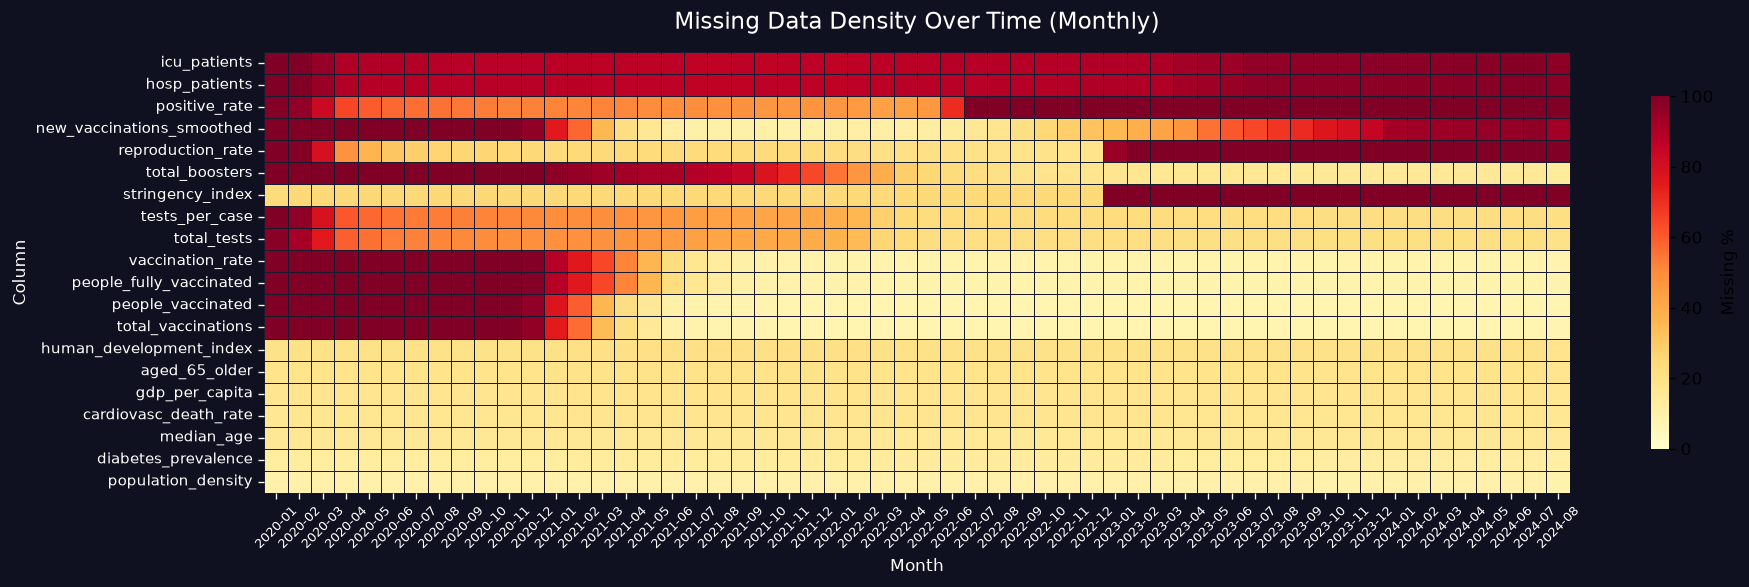


  Total confirmed cases :     775,592,504
  Total deaths          :       7,053,920
  Max single-day cases  :      40,475,477


In [3]:
# =============================================================================
# CELL 2 — Data Profile and Missing Value Heatmap
# =============================================================================

missing_pct = (covid_df.isnull().sum() / len(covid_df) * 100).sort_values(ascending=False)
missing_pct = missing_pct[missing_pct > 0]

print(f"Total rows      : {covid_df.shape[0]:,}")
print(f"Countries       : {covid_df['location'].nunique()}")
print(f"Date range      : {covid_df['date'].min().date()} → {covid_df['date'].max().date()}")
print(f"Columns with NA : {len(missing_pct)} / {covid_df.shape[1]}")

print("\n── Top 10 Columns with Highest Missing % ─────────────────")
for col, pct in missing_pct.head(10).items():
    bar = "█" * int(pct / 2)
    print(f"  {col:<35s}  {pct:5.1f}%  {bar}")

# Seaborn missing value heatmap
heatmap_cols = missing_pct[(missing_pct > 5) & (missing_pct < 95)].index.tolist()[:20]

if len(heatmap_cols) >= 2:
    temp = covid_df[["date"] + heatmap_cols].copy()
    temp["month"] = temp["date"].dt.to_period("M").astype(str)
    pivot = temp.groupby("month")[heatmap_cols].apply(lambda x: x.isnull().mean() * 100)

    fig_mv, ax = plt.subplots(figsize=(16, 5))
    sns.heatmap(pivot.T, cmap="YlOrRd", linewidths=0.3, linecolor="#1a1a2e",
                cbar_kws={"label": "Missing %", "shrink": 0.8}, ax=ax, vmin=0, vmax=100)
    ax.set_title("Missing Data Density Over Time (Monthly)", fontsize=14, pad=14, color="white")
    ax.set_xlabel("Month", color="white"); ax.set_ylabel("Column", color="white")
    ax.tick_params(axis="x", rotation=45, labelsize=8, colors="white")
    ax.tick_params(axis="y", labelsize=9, colors="white")
    fig_mv.patch.set_facecolor("#0f1120"); ax.set_facecolor("#1a1a2e")
    plt.tight_layout()
    plt.savefig("data/processed/analysis/missing_value_heatmap.png",
                dpi=120, bbox_inches="tight", facecolor="#0f1120")
    plt.show()

latest = covid_df.sort_values("date").groupby("location").last().reset_index()
print(f"\n  Total confirmed cases : {latest['total_cases'].sum():>15,.0f}")
print(f"  Total deaths          : {latest['total_deaths'].sum():>15,.0f}")
print(f"  Max single-day cases  : {covid_df['new_cases'].max():>15,.0f}")

## Cell 3 — Global Trends and Pandemic Progression

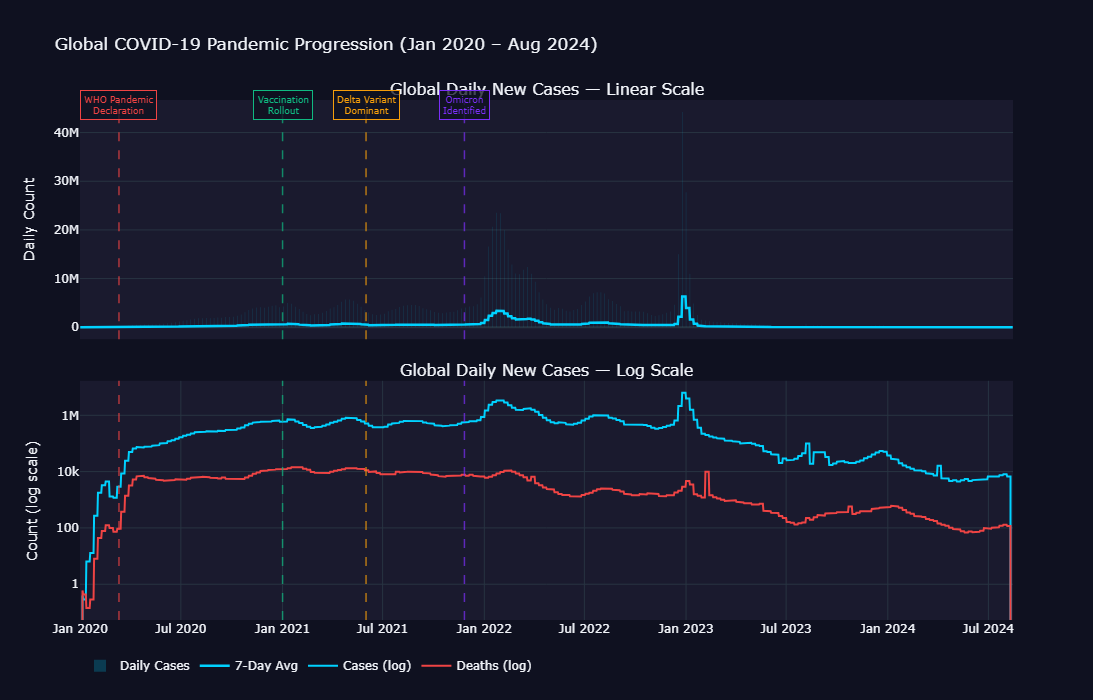

In [4]:
# =============================================================================
# CELL 3 — Global Trends and Pandemic Progression
# =============================================================================

global_daily = (
    covid_df.groupby("date", as_index=False)
    .agg(new_cases=("new_cases","sum"), new_deaths=("new_deaths","sum"))
    .sort_values("date")
)
global_daily["rolling_7d_cases"]  = global_daily["new_cases"].rolling(7, min_periods=1).mean()
global_daily["rolling_7d_deaths"] = global_daily["new_deaths"].rolling(7, min_periods=1).mean()
for col in ["new_cases","new_deaths","rolling_7d_cases","rolling_7d_deaths"]:
    global_daily[col] = global_daily[col].clip(lower=0)

MILESTONES = [
    {"date": "2020-03-11", "label": "WHO Pandemic<br>Declaration", "color": "#ef4444"},
    {"date": "2021-01-01", "label": "Vaccination<br>Rollout",      "color": "#10b981"},
    {"date": "2021-06-01", "label": "Delta Variant<br>Dominant",   "color": "#f59e0b"},
    {"date": "2021-11-26", "label": "Omicron<br>Identified",       "color": "#7b2ff7"},
]

fig3 = make_subplots(rows=2, cols=1, shared_xaxes=True,
                     subplot_titles=("Global Daily New Cases — Linear Scale",
                                     "Global Daily New Cases — Log Scale"),
                     vertical_spacing=0.08, row_heights=[0.5, 0.5])

fig3.add_trace(go.Bar(x=global_daily["date"], y=global_daily["new_cases"],
                      name="Daily Cases", marker_color="rgba(0,210,255,0.22)",
                      marker_line_width=0,
                      hovertemplate="%{x|%d %b %Y}<br>Cases: %{y:,.0f}<extra></extra>"),
               row=1, col=1)
fig3.add_trace(go.Scatter(x=global_daily["date"], y=global_daily["rolling_7d_cases"],
                          name="7-Day Avg", line=dict(color="#00d2ff", width=2.5),
                          hovertemplate="%{x|%d %b %Y}<br>7-Day Avg: %{y:,.0f}<extra></extra>"),
               row=1, col=1)
fig3.add_trace(go.Scatter(x=global_daily["date"], y=global_daily["rolling_7d_cases"],
                          name="Cases (log)", line=dict(color="#00d2ff", width=2)), row=2, col=1)
fig3.add_trace(go.Scatter(x=global_daily["date"], y=global_daily["rolling_7d_deaths"],
                          name="Deaths (log)", line=dict(color="#ef4444", width=2)), row=2, col=1)

for ms in MILESTONES:
    for r in [1, 2]:
        fig3.add_vline(x=ms["date"], line_color=ms["color"], line_width=1.5,
                       line_dash="dash", opacity=0.7, row=r, col=1)
    fig3.add_annotation(x=ms["date"], y=1.02, xref="x", yref="paper",
                        text=ms["label"], showarrow=False, font=dict(size=9, color=ms["color"]),
                        bgcolor="rgba(15,17,32,0.75)", bordercolor=ms["color"],
                        borderwidth=1, borderpad=3)

fig3.update_yaxes(type="log", row=2, col=1, title_text="Count (log scale)")
fig3.update_yaxes(title_text="Daily Count", row=1, col=1)
fig3.update_layout(template="plotly_dark",
                   title="Global COVID-19 Pandemic Progression (Jan 2020 – Aug 2024)",
                   height=700, paper_bgcolor="#0f1120", plot_bgcolor="#1a1a2e",
                   hovermode="x unified", legend=dict(orientation="h", y=-0.06))
fig3.show()

## Cell 4 — India Spotlight and Wave Analysis

scipy detected 6 peaks in India data.


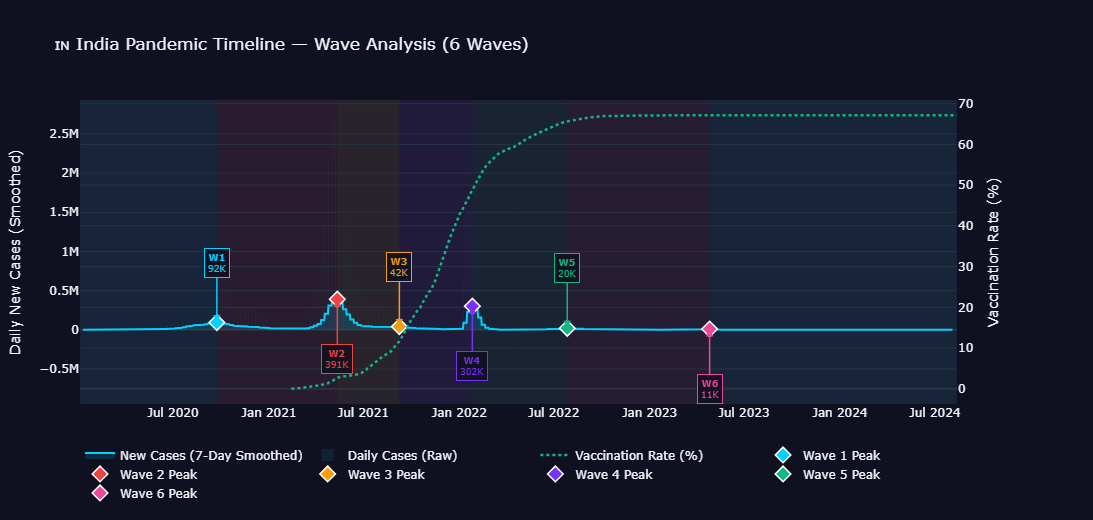

In [5]:
# =============================================================================
# CELL 4 — India Spotlight and Wave Analysis
# =============================================================================

india_df["date"] = pd.to_datetime(india_df["date"], errors="coerce")
india_df = india_df.sort_values("date").reset_index(drop=True)
if "new_cases_smoothed" not in india_df.columns:
    india_df["new_cases_smoothed"] = india_df["new_cases"].rolling(7, min_periods=1).mean()

WAVE_PEAK_DT = [pd.Timestamp(d) for d in [
    "2020-09-23","2021-05-12","2021-09-08","2022-01-26","2022-07-27","2023-04-26"]]

smooth_signal  = india_df["new_cases_smoothed"].fillna(0).values
scipy_peaks, _ = find_peaks(smooth_signal, distance=60, prominence=5000)
print(f"scipy detected {len(scipy_peaks)} peaks in India data.")

WAVE_COLOURS_BG = ["rgba(0,210,255,0.06)","rgba(239,68,68,0.08)","rgba(245,158,11,0.07)",
                   "rgba(123,47,247,0.07)","rgba(16,185,129,0.06)","rgba(236,72,153,0.06)"]
PEAK_COLOURS    = ["#00d2ff","#ef4444","#f59e0b","#7b2ff7","#10b981","#ec4899"]

data_start = india_df["date"].min()
data_end   = india_df["date"].max()
wave_boundaries = [data_start] + WAVE_PEAK_DT + [data_end]

fig4 = make_subplots(specs=[[{"secondary_y": True}]])

fig4.add_trace(go.Scatter(x=india_df["date"], y=india_df["new_cases_smoothed"],
                          fill="tozeroy", name="New Cases (7-Day Smoothed)",
                          fillcolor="rgba(0,210,255,0.15)", line=dict(color="#00d2ff", width=2),
                          hovertemplate="%{x|%d %b %Y}<br>Smoothed: %{y:,.0f}<extra></extra>"),
               secondary_y=False)
fig4.add_trace(go.Bar(x=india_df["date"], y=india_df["new_cases"], name="Daily Cases (Raw)",
                      marker_color="rgba(0,210,255,0.10)", marker_line_width=0), secondary_y=False)

if "vaccination_rate" in india_df.columns:
    fig4.add_trace(go.Scatter(x=india_df["date"], y=india_df["vaccination_rate"],
                              name="Vaccination Rate (%)", line=dict(color="#10b981", width=2.5, dash="dot"),
                              hovertemplate="%{x|%d %b %Y}<br>Vax: %{y:.1f}%<extra></extra>"),
                   secondary_y=True)

for i in range(len(wave_boundaries) - 1):
    fig4.add_vrect(x0=wave_boundaries[i], x1=wave_boundaries[i+1],
                   fillcolor=WAVE_COLOURS_BG[i % len(WAVE_COLOURS_BG)],
                   opacity=1, layer="below", line_width=0)

for i, (peak_date, colour) in enumerate(zip(WAVE_PEAK_DT, PEAK_COLOURS)):
    idx     = (india_df["date"] - peak_date).abs().idxmin()
    pval    = india_df.loc[idx, "new_cases_smoothed"]
    pdate   = india_df.loc[idx, "date"]
    fig4.add_trace(go.Scatter(x=[pdate], y=[pval], mode="markers",
                              name=f"Wave {i+1} Peak",
                              marker=dict(size=12, color=colour, symbol="diamond",
                                          line=dict(color="white", width=1.5))), secondary_y=False)
    fig4.add_annotation(x=pdate, y=pval,
                        text=f"<b>W{i+1}</b><br>{pval/1000:.0f}K",
                        showarrow=True, arrowhead=2, arrowcolor=colour, arrowwidth=1.5,
                        ax=0, ay=-60 if i%2==0 else 60,
                        font=dict(size=9, color=colour),
                        bgcolor="rgba(15,17,32,0.85)", bordercolor=colour,
                        borderwidth=1, borderpad=3)

fig4.update_layout(template="plotly_dark",
                   title="🇮🇳 India Pandemic Timeline — Wave Analysis (6 Waves)",
                   height=520, paper_bgcolor="#0f1120", plot_bgcolor="#1a1a2e",
                   hovermode="x unified", legend=dict(orientation="h", y=-0.12))
fig4.update_yaxes(title_text="Daily New Cases (Smoothed)", secondary_y=False)
fig4.update_yaxes(title_text="Vaccination Rate (%)", secondary_y=True)
fig4.show()

## Cell 5 — India vs Global Benchmark Comparison

      location  total_cases_per_million  total_deaths_per_million  vaccination_rate  cfr_pct
         India                      NaN                       NaN             67.18     1.18
 United States                302859.50                   3493.55             68.18     1.15
        Brazil                178367.94                   3338.54             81.82     1.87
United Kingdom                366308.00                   3404.43             75.19     0.93
 World Average                205704.13                   1259.00             57.61     1.23


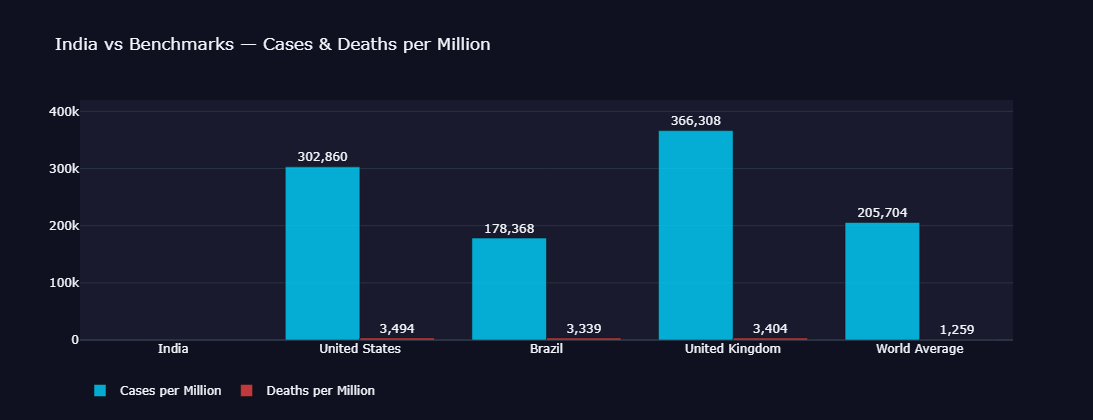

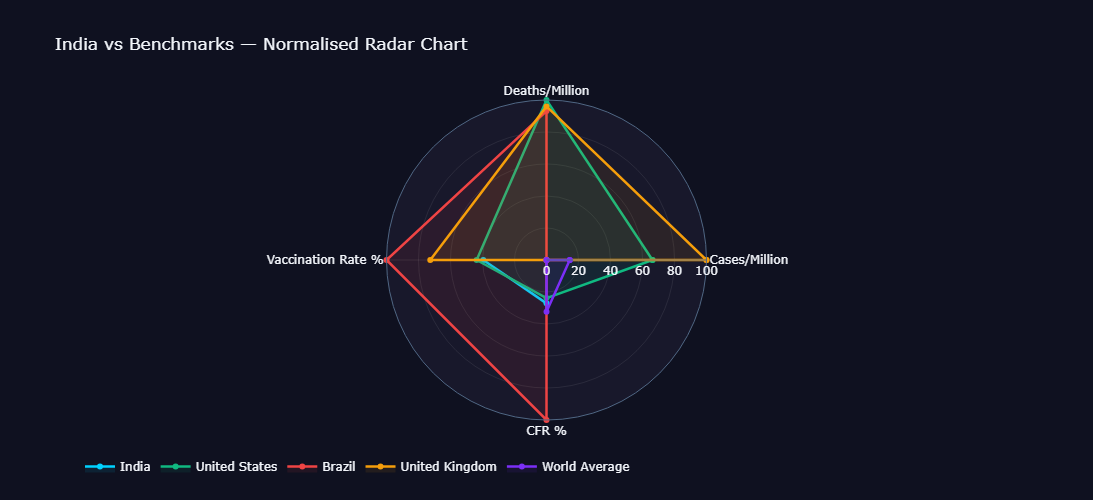

In [6]:
# =============================================================================
# CELL 5 — India vs Global Benchmark Comparison
# =============================================================================

BENCHMARKS = ["India","United States","Brazil","United Kingdom"]

def latest_snapshot(df, loc):
    sub = df[df["location"] == loc].sort_values("date")
    return sub.iloc[-1] if not sub.empty else pd.Series(dtype=float)

bench_rows = []
for loc in BENCHMARKS:
    row = latest_snapshot(covid_df, loc)
    if not row.empty:
        bench_rows.append({
            "location": loc,
            "total_cases_per_million":  row.get("total_cases_per_million",  np.nan),
            "total_deaths_per_million": row.get("total_deaths_per_million", np.nan),
            "vaccination_rate":         row.get("vaccination_rate",         np.nan),
            "case_fatality_rate":       row.get("case_fatality_rate",       np.nan),
        })

world_latest = covid_df.sort_values("date").groupby("location").last().reset_index()
bench_rows.append({
    "location": "World Average",
    "total_cases_per_million":  world_latest["total_cases_per_million"].mean(),
    "total_deaths_per_million": world_latest["total_deaths_per_million"].mean(),
    "vaccination_rate":         world_latest["vaccination_rate"].mean(),
    "case_fatality_rate":       world_latest["case_fatality_rate"].mean(),
})
bench_df = pd.DataFrame(bench_rows)
bench_df["cfr_pct"] = bench_df["case_fatality_rate"].apply(
    lambda v: v * 100 if pd.notna(v) and v <= 1 else v)

print(bench_df[["location","total_cases_per_million","total_deaths_per_million",
                "vaccination_rate","cfr_pct"]].to_string(index=False, float_format="{:.2f}".format))

# Grouped bar chart
fig5a = go.Figure()
for metric, label, colour in [
    ("total_cases_per_million",  "Cases per Million",  "rgba(0,210,255,0.8)"),
    ("total_deaths_per_million", "Deaths per Million", "rgba(239,68,68,0.8)"),
]:
    fig5a.add_trace(go.Bar(name=label, x=bench_df["location"], y=bench_df[metric],
                           marker_color=colour,
                           text=bench_df[metric].apply(lambda v: f"{v:,.0f}" if pd.notna(v) else ""),
                           textposition="outside",
                           hovertemplate=f"<b>%{{x}}</b><br>{label}: %{{y:,.0f}}<extra></extra>"))
fig5a.update_layout(template="plotly_dark", barmode="group", height=420,
                    title="India vs Benchmarks — Cases & Deaths per Million",
                    paper_bgcolor="#0f1120", plot_bgcolor="#1a1a2e",
                    legend=dict(orientation="h", y=-0.15))
fig5a.show()

# Radar chart
radar_metrics = ["total_cases_per_million","total_deaths_per_million","vaccination_rate","cfr_pct"]
radar_labels  = ["Cases/Million","Deaths/Million","Vaccination Rate %","CFR %"]
radar_norm = bench_df[["location"] + radar_metrics].copy()
for col in radar_metrics:
    lo, hi = radar_norm[col].min(), radar_norm[col].max()
    radar_norm[col] = (radar_norm[col] - lo) / (hi - lo + 1e-9) * 100

RADAR_COLOURS = {"India":"#00d2ff","United States":"#10b981","Brazil":"#ef4444",
                 "United Kingdom":"#f59e0b","World Average":"#7b2ff7"}
theta = radar_labels + [radar_labels[0]]
fig5b = go.Figure()
for _, row in radar_norm.iterrows():
    loc    = row["location"]
    values = [row[m] for m in radar_metrics] + [row[radar_metrics[0]]]
    colour = RADAR_COLOURS.get(loc, "#888")
    rt     = tuple(int(colour.lstrip("#")[i:i+2], 16) for i in (0,2,4))
    fig5b.add_trace(go.Scatterpolar(r=values, theta=theta, fill="toself", name=loc,
                                    line=dict(color=colour, width=2.5),
                                    fillcolor=f"rgba{rt+(0.09,)}"))
fig5b.update_layout(template="plotly_dark",
                    title="India vs Benchmarks — Normalised Radar Chart",
                    polar=dict(bgcolor="rgba(26,26,46,0.8)",
                               radialaxis=dict(visible=True, range=[0,100],
                                              gridcolor="rgba(255,255,255,0.08)"),
                               angularaxis=dict(gridcolor="rgba(255,255,255,0.08)")),
                    height=500, paper_bgcolor="#0f1120",
                    legend=dict(orientation="h", y=-0.10))
fig5b.show()

## Cell 6 — Vaccination Impact Analysis

Pearson  r  = -0.4716  (p = 0.000000)
Spearman ρ  = -0.5540  (p = 0.000000)


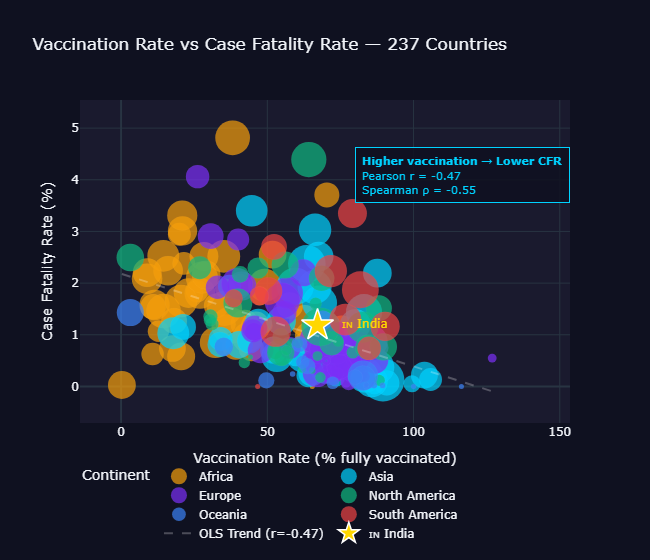

In [7]:
# =============================================================================
# CELL 6 — Vaccination Impact Analysis
# =============================================================================

df6 = summary_df.copy()
if "case_fatality_rate" in df6.columns:
    df6["cfr_pct"] = df6["case_fatality_rate"].apply(
        lambda v: v * 100 if pd.notna(v) and v <= 1 else v)
else:
    df6["cfr_pct"] = df6["total_deaths"] / df6["total_cases"].replace(0, np.nan) * 100

vax_col = "vaccination_rate"
valid   = df6.dropna(subset=[vax_col,"cfr_pct"]).copy()
valid   = valid[(valid[vax_col] > 0) & (valid["cfr_pct"] < valid["cfr_pct"].quantile(0.98))]

z      = np.polyfit(valid[vax_col], valid["cfr_pct"], 1)
x_line = np.linspace(valid[vax_col].min(), valid[vax_col].max(), 200)
y_line = np.polyval(z, x_line)

live_pr, live_pp = scipy_stats.pearsonr( valid[vax_col], valid["cfr_pct"])
live_sr, live_sp = scipy_stats.spearmanr(valid[vax_col], valid["cfr_pct"])
print(f"Pearson  r  = {live_pr:.4f}  (p = {live_pp:.6f})")
print(f"Spearman ρ  = {live_sr:.4f}  (p = {live_sp:.6f})")

CONT_PALETTE = {"Asia":"#00d2ff","Europe":"#7b2ff7","North America":"#10b981",
                "South America":"#ef4444","Africa":"#f59e0b","Oceania":"#3b82f6"}

fig6 = go.Figure()
for cont in sorted(valid["continent"].dropna().unique() if "continent" in valid.columns else []):
    sub = valid[(valid["continent"] == cont) &
                (~valid.get("location", valid.get("iso_code", pd.Series())).str.lower().str.contains("india", na=False))]
    if sub.empty: continue
    if "population" in sub.columns:
        pop_norm = np.clip((np.log10(sub["population"].fillna(1e6).clip(lower=1e4)) - 4) /
                           (np.log10(1.5e9) - 4), 0, 1)
        msize = 5 + pop_norm * 38
    else:
        msize = 8
    loc_col = "location" if "location" in sub.columns else "iso_code"
    fig6.add_trace(go.Scatter(x=sub[vax_col], y=sub["cfr_pct"], mode="markers", name=cont,
                              marker=dict(size=msize, color=CONT_PALETTE.get(cont,"#888"),
                                          opacity=0.70, sizemode="diameter",
                                          line=dict(color="rgba(255,255,255,0.07)", width=0.5)),
                              text=sub[loc_col],
                              hovertemplate="<b>%{text}</b><br>Vax: %{x:.1f}%<br>CFR: %{y:.3f}%<extra></extra>"))

fig6.add_trace(go.Scatter(x=x_line, y=y_line, mode="lines",
                          name=f"OLS Trend (r={live_pr:.2f})",
                          line=dict(color="rgba(255,255,255,0.25)", width=2, dash="dash"),
                          hoverinfo="skip"))

india_r = valid[valid.get("location", valid.get("iso_code", pd.Series())) == "India"]
if india_r.empty and "iso_code" in valid.columns:
    india_r = valid[valid["iso_code"] == "IND"]
if not india_r.empty:
    fig6.add_trace(go.Scatter(x=[india_r[vax_col].values[0]], y=[india_r["cfr_pct"].values[0]],
                              mode="markers+text", name="🇮🇳 India",
                              marker=dict(size=24, color="#ffd700", symbol="star",
                                          line=dict(color="white", width=1.5)),
                              text=["  🇮🇳 India"], textposition="middle right",
                              textfont=dict(color="#ffd700", size=12)))

fig6.add_annotation(x=valid[vax_col].max()*0.92, y=valid["cfr_pct"].max()*0.85,
                    text=f"<b>Higher vaccination → Lower CFR</b><br>Pearson r = {live_pr:.2f}<br>Spearman ρ = {live_sr:.2f}",
                    showarrow=False, font=dict(size=11, color="#00d2ff"), align="left",
                    bgcolor="rgba(15,17,32,0.85)", bordercolor="#00d2ff",
                    borderwidth=1, borderpad=6)

fig6.update_layout(template="plotly_dark",
                   title="Vaccination Rate vs Case Fatality Rate — 237 Countries",
                   xaxis_title="Vaccination Rate (% fully vaccinated)",
                   yaxis_title="Case Fatality Rate (%)",
                   height=560, paper_bgcolor="#0f1120", plot_bgcolor="#1a1a2e",
                   legend=dict(orientation="h", y=-0.12), legend_title_text="Continent")
fig6.show()

## Cell 7 — Country Risk Scoring and Bubble Chart


── Top 10 Highest-Risk Countries ─────────────────────────
              location continent  vaccination_rate  composite_risk_score
              Slovenia    Europe           57.6564                0.7066
               Georgia      Asia           34.0823                0.6940
            San Marino    Europe           70.1484                0.6651
              Bulgaria    Europe           30.6402                0.6316
            Montenegro    Europe           45.4277                0.6103
                Latvia    Europe           70.5684                0.5827
Bosnia and Herzegovina    Europe           26.1658                0.5805
               Croatia    Europe           55.8711                0.5731
                Greece    Europe           73.6360                0.5722
               Czechia    Europe           65.7115                0.5688


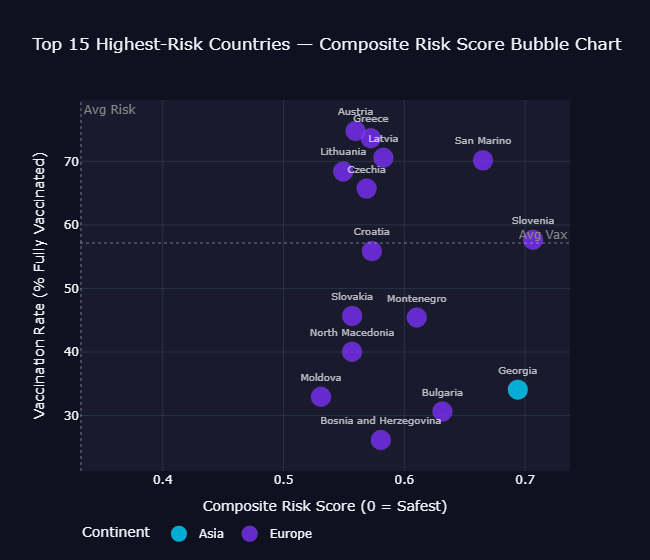


✅  All 7 notebook cells executed successfully.


In [8]:
# =============================================================================
# CELL 7 — Country Risk Scoring and Bubble Chart
# =============================================================================

df7 = risk_df.copy()
RISK_SCORE_COL = next((c for c in df7.columns if "composite_risk" in c.lower()), None)
VAX_COL7  = next((c for c in df7.columns if "vaccination_rate" in c.lower()), None)
LOC_COL7  = "location" if "location" in df7.columns else "iso_code"
CONT_COL7 = "continent" if "continent" in df7.columns else None
POP_COL7  = "population" if "population" in df7.columns else None

if RISK_SCORE_COL is None:
    def mnmx(s): lo,hi=s.min(),s.max(); return (s-lo)/(hi-lo+1e-9)
    df7["composite_risk_score"] = (
        mnmx(df7.get("case_fatality_rate", pd.Series(0, index=df7.index))) * 0.4 +
        mnmx(df7.get("total_deaths_per_million", pd.Series(0, index=df7.index))) * 0.4 +
        (1 - mnmx(df7.get(VAX_COL7, pd.Series(0, index=df7.index)))) * 0.2)
    RISK_SCORE_COL = "composite_risk_score"

df7 = df7.sort_values(RISK_SCORE_COL, ascending=False).reset_index(drop=True)
top15 = df7.head(15).copy()

print("\n── Top 10 Highest-Risk Countries ─────────────────────────")
print_cols = [c for c in [LOC_COL7, CONT_COL7, VAX_COL7, RISK_SCORE_COL] if c and c in df7.columns]
print(df7.head(10)[print_cols].to_string(index=False, float_format="{:.4f}".format))

fig7 = go.Figure()
cont_vals = top15[CONT_COL7] if CONT_COL7 else pd.Series(["Unknown"]*len(top15))
for cont in sorted(cont_vals.dropna().unique()):
    mask = cont_vals == cont
    sub7 = top15[mask]
    is_india = sub7[LOC_COL7].str.lower().str.contains("india", na=False)
    if POP_COL7 and POP_COL7 in sub7.columns:
        pop_norm = np.clip((np.log10(sub7[POP_COL7].fillna(1e6).clip(lower=1e4))-4)/(np.log10(1.5e9)-4),0,1)
        msize7   = (14 + pop_norm * 54).values
    else:
        msize7 = 20

    sub_ni = sub7[~is_india]
    if len(sub_ni):
        ms_ni = msize7[~is_india.values] if hasattr(msize7,"__len__") else msize7
        fig7.add_trace(go.Scatter(
            x=sub_ni[RISK_SCORE_COL], y=sub_ni[VAX_COL7] if VAX_COL7 else [0]*len(sub_ni),
            mode="markers+text", name=cont,
            marker=dict(size=ms_ni, color=CONT_PALETTE.get(cont,"#888"),
                        opacity=0.80, sizemode="diameter",
                        line=dict(color="rgba(255,255,255,0.10)", width=0.8)),
            text=sub_ni[LOC_COL7], textposition="top center",
            textfont=dict(size=10, color="rgba(255,255,255,0.7)"),
            hovertemplate="<b>%{text}</b><br>Risk: %{x:.4f}<br>Vax: %{y:.1f}%<extra></extra>"))

    sub_in = sub7[is_india]
    if len(sub_in):
        fig7.add_trace(go.Scatter(
            x=sub_in[RISK_SCORE_COL], y=sub_in[VAX_COL7] if VAX_COL7 else [0],
            mode="markers+text", name="🇮🇳 India",
            marker=dict(size=30, color="#ffd700", symbol="star",
                        line=dict(color="white", width=1.5)),
            text=["  🇮🇳 India"], textposition="middle right",
            textfont=dict(size=12, color="#ffd700"),
            hovertemplate="<b>🇮🇳 India</b><br>Risk: %{x:.4f}<br>Vax: %{y:.1f}%<extra></extra>"))

fig7.add_vline(x=df7[RISK_SCORE_COL].mean(), line_color="rgba(255,255,255,0.2)",
               line_dash="dot", annotation_text="Avg Risk", annotation_font_color="#888")
if VAX_COL7 and VAX_COL7 in df7.columns:
    fig7.add_hline(y=df7[VAX_COL7].mean(), line_color="rgba(255,255,255,0.2)",
                   line_dash="dot", annotation_text="Avg Vax", annotation_font_color="#888")

fig7.update_layout(template="plotly_dark",
                   title="Top 15 Highest-Risk Countries — Composite Risk Score Bubble Chart",
                   xaxis_title="Composite Risk Score (0 = Safest)",
                   yaxis_title="Vaccination Rate (% Fully Vaccinated)",
                   height=560, paper_bgcolor="#0f1120", plot_bgcolor="#1a1a2e",
                   legend=dict(orientation="h", y=-0.13), legend_title_text="Continent")
fig7.show()
print("\n✅  All 7 notebook cells executed successfully.")